In [10]:
from quantum_function import *

## Joint homodyne
$d \varrho = -i \left[ H_{atoms}, \varrho\right] + \gamma \mathcal{D}\left[\sigma_{z}^{(1)}\right]\varrho+\gamma \mathcal{D}\left[\sigma_{z}^{(2)}\right]\varrho = -i \left[ H, \varrho\right] + \gamma \mathcal{D}\left[ \dfrac{\sigma_{z}^{(1)}+\sigma_{z}^{(2)}}{\sqrt{2}}\right]\varrho+\gamma \mathcal{D}\left[ \dfrac{\sigma_{z}^{(1)}-\sigma_{z}^{(2)}}{\sqrt{2}}\right]\varrho$

In [7]:
#1000 in 2 min

gamma = 1             # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.005*T_1)) # time vector

my_name_states = ["++","css_theta=pi/6"]

my_initial_states = [
    css_2(np.pi/2, phi=0),
    css_2(np.pi/6, phi=0)
]

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

ntraj = 1000 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = ssesolve(
        H_free, state, times,
        sc_ops = [
        np.sqrt(gamma / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi/2) * np.sqrt(gamma / 2) * (Sz_1-Sz_2)
        ],
        e_ops=[concurrence_for_solver_pure],
        ntraj=ntraj,
        heterodyne=False,
        options={"keep_runs_results": True, "map":"parallel"}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)

10.0%. Run time:  46.29s. Est. time left: 00:00:06:56
20.0%. Run time:  67.20s. Est. time left: 00:00:04:28
30.0%. Run time:  91.78s. Est. time left: 00:00:03:34
40.0%. Run time: 121.76s. Est. time left: 00:00:03:02
50.0%. Run time: 154.20s. Est. time left: 00:00:02:34
60.0%. Run time: 193.39s. Est. time left: 00:00:02:08
70.0%. Run time: 228.86s. Est. time left: 00:00:01:38
80.0%. Run time: 265.05s. Est. time left: 00:00:01:06
90.0%. Run time: 300.01s. Est. time left: 00:00:00:33
100.0%. Run time: 334.43s. Est. time left: 00:00:00:00
Total run time: 336.40s
10.0%. Run time:  50.51s. Est. time left: 00:00:07:34
20.0%. Run time:  96.20s. Est. time left: 00:00:06:24
30.0%. Run time: 131.10s. Est. time left: 00:00:05:05
40.0%. Run time: 162.90s. Est. time left: 00:00:04:04
50.0%. Run time: 195.22s. Est. time left: 00:00:03:15
60.0%. Run time: 227.70s. Est. time left: 00:00:02:31
70.0%. Run time: 258.80s. Est. time left: 00:00:01:50
80.0%. Run time: 292.55s. Est. time left: 00:00:01:13
90.

In [3]:
#photodetection_dfs["ee"]

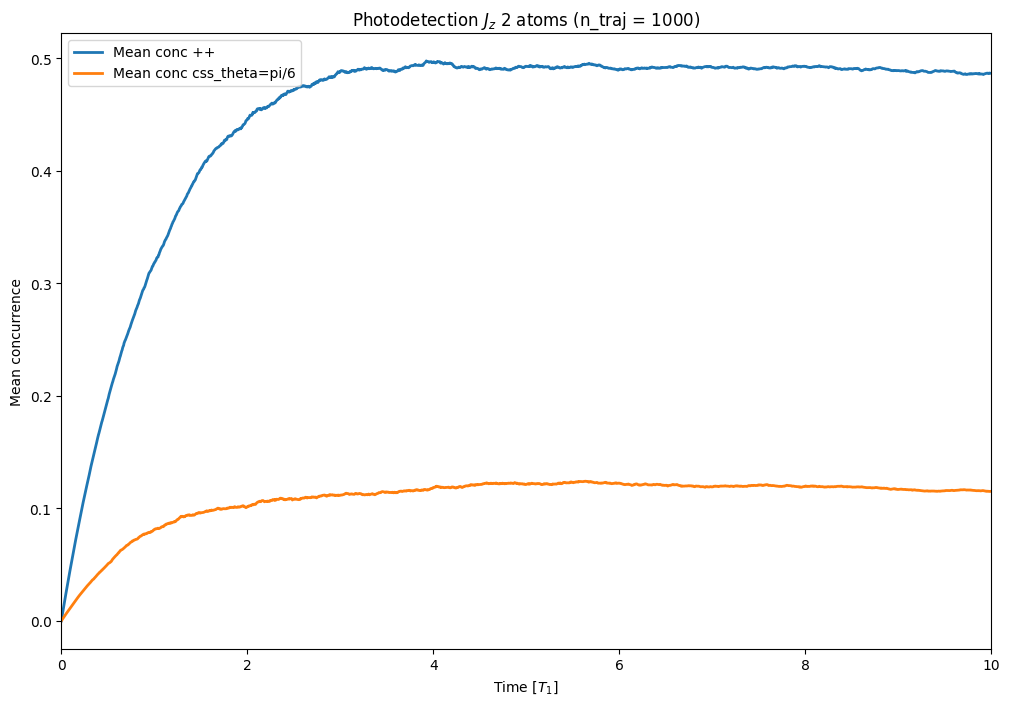

In [9]:
plt.figure(figsize=(12,8))

theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]


for state,theory in zip(my_name_states, theo_curves):
    line_sim, = plt.plot(times/T_1, photodetection_dfs[f"{state}"]['mean'], label=f"Mean conc {state}", linewidth=2)
    #plt.plot(times/T_1, theory, '--', label=f"Theo conc", color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.xlim(0, 10)
plt.xlabel(r"Time [$T_1$]")
plt.ylabel("Mean concurrence")
plt.title(fr"Photodetection $J_z$ 2 atoms (n_traj = {ntraj})")
plt.legend()
plt.show()

Varying the homodyning angle

In [24]:
gamma = 1             # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 5*T_1, 0.001*T_1)) # time vector

my_theta = [0, 1/6, 1/3, 1/2] # angles for the homodyne detection
my_name_theta = ["0","pi/6","pi/3","pi/2"]

#Creo dict di dataframe per ogni stato iniziale
homodyne_dfs = {}

ntraj = 100 # number of trajectories

state = css_2(np.pi/2, phi=0) # initial state, |++>

# solve the master equation using montecarlo equation (photodetection) for every intial state
for theta, name_theta in zip(my_theta, my_name_theta):
    my_homodyne = ssesolve(
        H_free, state, times,
        sc_ops = [
        np.sqrt(gamma / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi* theta) * np.sqrt(gamma / 2) * (Sz_1-Sz_2)
        ],
        e_ops=[concurrence_for_solver_pure],
        ntraj=ntraj,
        heterodyne=False,
        options={"keep_runs_results": True, "map":"parallel"}, #Necessary to create the keep the e_ops results for each trajectory
    )

    homodyne_dfs[f"{name_theta}"] = pd.DataFrame(my_homodyne.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    homodyne_dfs[f"{name_theta}"].index = np.arange(1, homodyne_dfs[f"{name_theta}"].shape[0]+1)
    homodyne_dfs[f"{name_theta}"].index.name = "Step"
    homodyne_dfs[f"{name_theta}"]['mean'] = homodyne_dfs[f"{name_theta}"].mean(axis=1)

10.0%. Run time:  13.95s. Est. time left: 00:00:02:05
20.0%. Run time:  15.76s. Est. time left: 00:00:01:03
30.0%. Run time:  17.74s. Est. time left: 00:00:00:41
40.0%. Run time:  19.34s. Est. time left: 00:00:00:29
50.0%. Run time:  21.36s. Est. time left: 00:00:00:21
60.0%. Run time:  23.00s. Est. time left: 00:00:00:15
70.0%. Run time:  24.62s. Est. time left: 00:00:00:10
80.0%. Run time:  26.49s. Est. time left: 00:00:00:06
90.0%. Run time:  28.28s. Est. time left: 00:00:00:03
100.0%. Run time:  29.76s. Est. time left: 00:00:00:00
Total run time:  30.72s
10.0%. Run time:  11.20s. Est. time left: 00:00:01:40
20.0%. Run time:  12.79s. Est. time left: 00:00:00:51
30.0%. Run time:  14.66s. Est. time left: 00:00:00:34
40.0%. Run time:  16.67s. Est. time left: 00:00:00:25
50.0%. Run time:  18.69s. Est. time left: 00:00:00:18
60.0%. Run time:  20.59s. Est. time left: 00:00:00:13
70.0%. Run time:  23.03s. Est. time left: 00:00:00:09
80.0%. Run time:  25.73s. Est. time left: 00:00:00:06
90.

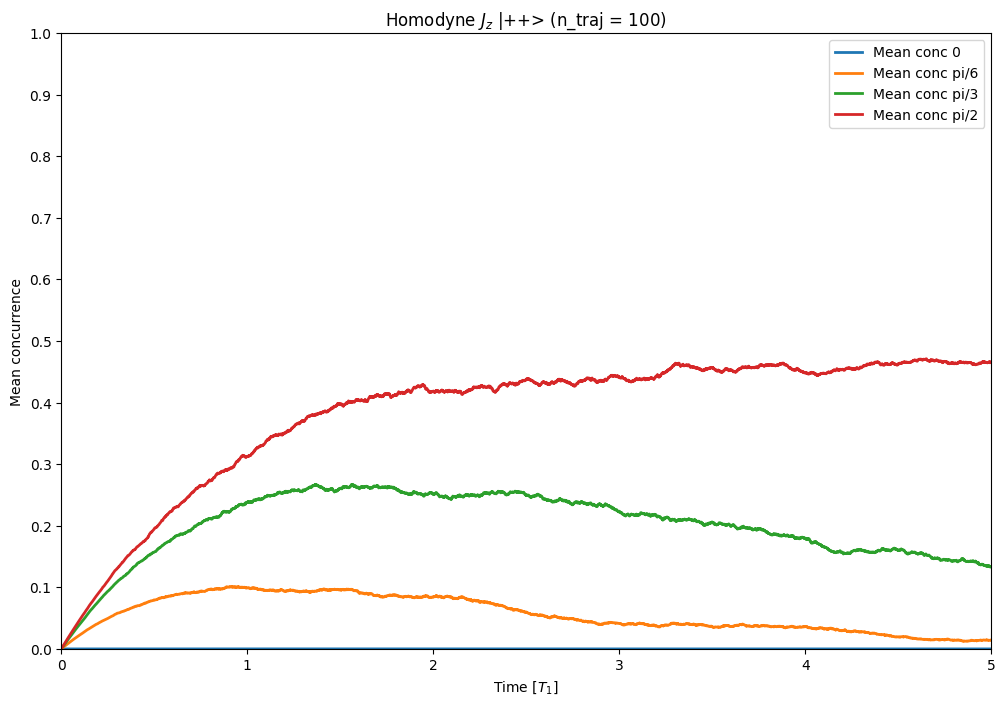

In [31]:
plt.figure(figsize=(12,8))

#le tengo per il futuro
theo_curves = [np.sin(theta*np.pi)**2 *(1-np.exp(-gamma/2*times)) for theta in my_theta]

for theta,theory in zip(my_name_theta, theo_curves):
    line_sim, = plt.plot(times/T_1, homodyne_dfs[f"{theta}"]['mean'], label=f"Mean conc {theta}", linewidth=2)
    #plt.plot(times/T_1, theory, '--', label=f"Theo conc", color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.xlim(0, 5)
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.xlabel(r"Time [$T_1$]")
plt.ylabel("Mean concurrence")
plt.title(fr"Homodyne $J_z$ |++> (n_traj = {ntraj})")
plt.legend()
plt.show()

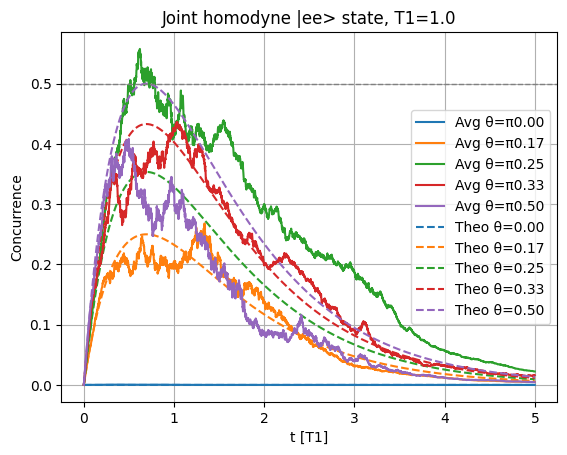

In [ ]:
line_theta = []
line_theo = []

for i, theta in enumerate(my_theta):
    # plottiamo la curva per il theta i-esimo
    line_theta_temp, = plt.plot(times, mean_conc_ee_solutions_jhom[i], label=f"Avg θ=π{(theta):.2f}")
    line_theta.append(line_theta_temp)

    line_theor_temp, = plt.plot(times, theo_concurrence(times, GAMMA)*np.sin(np.pi*theta), color=line_theta_temp.get_color(), linestyle ='--', label=f"Theo θ={theta:.2f}")
    line_theo.append(line_theor_temp)

#line2, = plt.plot(times, conc_ee_solutions_jhom[11], label="Trajectory #10")
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='y = 0.5')
#plt.axhline(y=1, color='red', linestyle='-', linewidth=1.5, label='y = 1')

plt.xlabel("t [T1]")
plt.ylabel("Concurrence")
plt.title(f"Joint homodyne |ee> state, T1={T_1}")
plt.grid(True)
plt.legend(handles = line_theta + line_theo)
plt.show()

In [ ]:
from joblib import Parallel, delayed

# Parametri
GAMMA = 1              # Atom decay rate
T_1 = 1 / GAMMA        # time constant for the decay
times = np.arange(0, 5*T_1, 0.001*T_1) # time vector

my_theta = [0, 1/6, 1/4, 1/3, 1/2]   # angles for homodyne detection
ntraj = 1000

mean_conc_ee_solutions_jhom = []

# ---- Funzione da parallelizzare ----
def run_simulation(theta):
    sc_ops = [
        np.sqrt(GAMMA / 2) * (sigma_minus_1 + sigma_minus_2),
        np.exp(1j * np.pi * theta) * np.sqrt(GAMMA / 2) * (sigma_minus_1 - sigma_minus_2)
    ]

    my_exp = ssesolve(
        H_free, ee, times,
        sc_ops=sc_ops,
        ntraj=ntraj,
        e_ops=[pop_excited_for_solver],
        options={"dt": 0.001, "map": "serial"}  # <--- usa seriale, niente "parallel"
    )

    mean_conc = my_exp.expect[0]
    return mean_conc

# ---- Parallelizzazione con joblib ----
if __name__ == "__main__":
    results = Parallel(n_jobs=-1)(delayed(run_simulation)(theta) for theta in my_theta)
    mean_conc_ee_solutions_jhom.extend(results)


In [9]:
GAMMA = 1
T_1 = 1 / GAMMA
times = np.arange(0, 5*T_1, 0.001*T_1)
ntraj = 100

def run_single_traj(theta):
    sc_ops = [
        np.sqrt(GAMMA / 2) * (sigma_minus_1 + sigma_minus_2),
        np.exp(1j * np.pi * theta) * np.sqrt(GAMMA / 2) * (sigma_minus_1 - sigma_minus_2)
    ]
    # Una singola traiettoria (ntraj=1) con seed fisso
    my_exp = ssesolve(
        H_free, ee, times,
        sc_ops=sc_ops,
        ntraj=1,
        e_ops=[concurrence_for_solver_pure],
        options={"dt": 0.001, "map": "serial"},
    )
    return my_exp.expect[0]

def run_theta(theta, ntraj):
    traj_results = Parallel(n_jobs=-1)(
        delayed(run_single_traj)(theta) for _ in range(ntraj)
    )
    # Media sulle traiettorie
    return np.mean(traj_results, axis=0)

if __name__ == "__main__":
    my_theta = [0, 1/6, 1/4, 1/3, 1/2]
    results = Parallel(n_jobs=len(my_theta))(
        delayed(run_theta)(theta, ntraj) for theta in my_theta
    )


# Inefficient joint homodyne detection
## $\sqrt{\gamma} \rightarrow \sqrt{\gamma \cdot \eta} $ and $\theta=\pi/2$

In [2]:
GAMMA = 1             # Atom decay rate
T_1 = 1 / GAMMA  # time constant for the decay

times = np.array(np.arange(0, 5*T_1, 0.01*T_1)) # time vector

#my_theta = [0, 1/6, 1/4, 1/3, 1/2] # angles for the homodyne detection in unit of pi
my_eta = [1, 0.9, 0.7, 0.5, 0.3] #etas for the homodyne detection

ntraj = 100

mean_conc_ee_solutions_jhom_ineff = []

for eta in my_eta:       
        my_c_ops = [
        np.sqrt(GAMMA*(1-eta) / 2) * (Sz_1+Sz_2),
        np.sqrt(GAMMA*(1-eta) / 2) * (Sz_1-Sz_2)*np.exp(1j * np.pi/2)
    ]
        
        my_sc_ops = [
        np.sqrt(GAMMA*eta / 2) * (Sz_1+Sz_2),
        np.sqrt(GAMMA*eta / 2) * (Sz_1-Sz_2) * np.exp(1j * np.pi/2)
    ]
        
        jhom_ineff = smesolve(
            H_free, ee.proj(), times,
            c_ops = my_c_ops,
            sc_ops = my_sc_ops, 
            e_ops = [concurrence_for_solver_pure],
            ntraj=ntraj,
            options={"map":"parallel"},
        )

        mean_conc = jhom_ineff.expect[0]

        mean_conc_ee_solutions_jhom_ineff.append(mean_conc)

10.0%. Run time: 10812.00s. Est. time left: 01:03:01:48
20.0%. Run time: 10812.83s. Est. time left: 00:12:00:51
30.0%. Run time: 10813.55s. Est. time left: 00:07:00:31
40.0%. Run time: 10814.22s. Est. time left: 00:04:30:21
50.0%. Run time: 10814.89s. Est. time left: 00:03:00:14
60.0%. Run time: 10815.50s. Est. time left: 00:02:00:10
70.0%. Run time: 10816.16s. Est. time left: 00:01:17:15
80.0%. Run time: 10816.81s. Est. time left: 00:00:45:04
90.0%. Run time: 10817.51s. Est. time left: 00:00:20:01
100.0%. Run time: 10818.03s. Est. time left: 00:00:00:00
Total run time: 10818.89s
10.0%. Run time: 3685.52s. Est. time left: 00:09:12:49
20.0%. Run time: 3691.54s. Est. time left: 00:04:06:06
30.0%. Run time: 3692.75s. Est. time left: 00:02:23:36
40.0%. Run time: 3694.07s. Est. time left: 00:01:32:21
50.0%. Run time: 3699.29s. Est. time left: 00:01:01:39
60.0%. Run time: 3701.68s. Est. time left: 00:00:41:07
70.0%. Run time: 3702.78s. Est. time left: 00:00:26:26
80.0%. Run time: 3708.49s. E

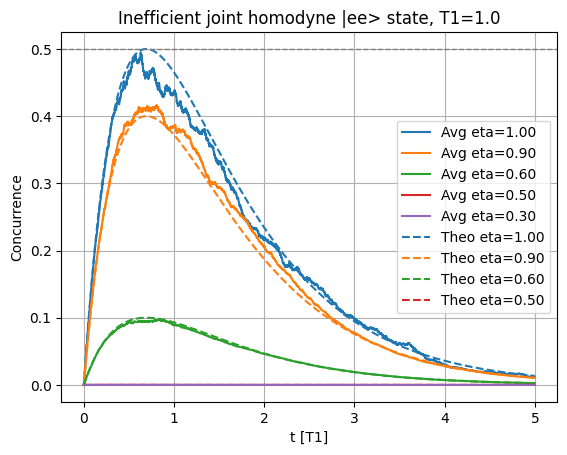

In [11]:
line_eta = []
line_theo_eta = []

for i, eta in enumerate(my_eta):
    # plottiamo la curva per il theta i-esimo
    line_eta_temp, = plt.plot(times, mean_conc_ee_solutions_jhom_ineff[i], label=f"Avg eta={(eta):.2f}")
    line_eta.append(line_eta_temp)

    if eta >= 0.5:
        line_theor_temp, = plt.plot(times, theo_concurrence(times, GAMMA)*(2*eta-1), color=line_eta_temp.get_color(), linestyle ='--', label=f"Theo eta={eta:.2f}")
        line_theo_eta.append(line_theor_temp)

#line2, = plt.plot(times, conc_ee_solutions_jhom[11], label="Trajectory #10")
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='y = 0.5')
#plt.axhline(y=1, color='red', linestyle='-', linewidth=1.5, label='y = 1')

plt.xlabel("t [T1]")
plt.ylabel("Concurrence")
plt.title(f"Inefficient joint homodyne |ee> state, T1={T_1}")
plt.grid(True)
plt.legend(handles = line_eta + line_theo_eta)
plt.show()

## Joint homodyne with css states

$|\theta, \phi\rangle = \bigotimes_{i=1}^N \left( \cos\frac{\theta}{2}\,|0\rangle_i + e^{i\phi}\sin\frac{\theta}{2}\,|1\rangle_i \right)$

x=theta se uso coordinate polari

In [4]:
def css_2(theta, phi):
    single_qubit = (np.sin(theta/2) * basis(2,0) + np.exp(1j*phi) * np.cos(theta/2) * basis(2,1))
    return tensor(single_qubit, single_qubit)

In [11]:
gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 5*T_1, 0.001*T_1)) # time vector

my_initial_states = [css_2(np.pi/theta, 0) for theta in [2,3,4,6,1]]
my_name_states = [f"css_theta_{theta}" for theta in [2,3,4,6,1]]

#Creo dict di dataframe per ogni stato iniziale
hom_dfs = {}

theo_curves = [
    (1-np.exp(-gamma * times)),
    (1-np.exp(-2*gamma * times)),
    (1-np.exp(-2*gamma * times)),
    (1-np.exp(-2*gamma * times)),
]

sigma_z_1 = tensor(sigmaz(), qeye(2))
sigma_z_2 = tensor(qeye(2), sigmaz())

ntraj = 500 # number of trajectories


# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_hom = ssesolve(
        H_free, state, times,
        
        sc_ops = [
        np.sqrt(gamma / 2) * (sigma_minus_1 + sigma_minus_2),
        np.exp(1j * np.pi /2) * np.sqrt(gamma / 2) * (sigma_minus_1 - sigma_minus_2)
        ],

        heterodyne=False,
        e_ops=[concurrence_for_solver_pure],
        ntraj=ntraj,
        options={"keep_runs_results": True, "map": "parallel"}, #Necessary to create the keep the e_ops results for each trajectory
    )

    hom_dfs[f"{name_state}"] = pd.DataFrame(my_hom.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    hom_dfs[f"{name_state}"].index = np.arange(1, hom_dfs[f"{name_state}"].shape[0]+1)
    hom_dfs[f"{name_state}"].index.name = "Step"
    hom_dfs[f"{name_state}"]['mean'] = hom_dfs[f"{name_state}"].mean(axis=1)


10.0%. Run time:  16.96s. Est. time left: 00:00:02:32
20.0%. Run time:  25.13s. Est. time left: 00:00:01:40
30.0%. Run time:  33.43s. Est. time left: 00:00:01:18
40.0%. Run time:  42.38s. Est. time left: 00:00:01:03
50.0%. Run time:  51.39s. Est. time left: 00:00:00:51
60.0%. Run time:  60.55s. Est. time left: 00:00:00:40
70.0%. Run time:  70.58s. Est. time left: 00:00:00:30
80.0%. Run time:  87.04s. Est. time left: 00:00:00:21
90.0%. Run time: 101.67s. Est. time left: 00:00:00:11
100.0%. Run time: 114.02s. Est. time left: 00:00:00:00
Total run time: 115.23s
10.0%. Run time:  67.72s. Est. time left: 00:00:10:09
20.0%. Run time:  95.81s. Est. time left: 00:00:06:23
30.0%. Run time: 123.03s. Est. time left: 00:00:04:47
40.0%. Run time: 142.03s. Est. time left: 00:00:03:33
50.0%. Run time: 163.96s. Est. time left: 00:00:02:43
60.0%. Run time: 182.94s. Est. time left: 00:00:02:01
70.0%. Run time: 208.25s. Est. time left: 00:00:01:29
80.0%. Run time: 227.18s. Est. time left: 00:00:00:56
90.

In [16]:
hom_dfs["css_theta_2"]

,Traj_1,Traj_2,Traj_3,Traj_4,Traj_5,Traj_6,Traj_7,Traj_8,Traj_9,Traj_10,...,Traj_492,Traj_493,Traj_494,Traj_495,Traj_496,Traj_497,Traj_498,Traj_499,Traj_500,mean
Step,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000502,0.000473,0.000503,0.000481,0.000498,0.000489,0.000499,0.000508,0.000500,0.000523,...,0.000503,0.000496,0.000500,0.000500,0.000500,0.000500,0.000490,0.000500,0.000517,0.000501
3,0.000894,0.000973,0.001048,0.000940,0.000994,0.000971,0.000980,0.001011,0.001051,0.000995,...,0.001021,0.000986,0.001171,0.000959,0.001004,0.000997,0.000953,0.000980,0.001057,0.001001
4,0.001370,0.001447,0.001550,0.001411,0.001431,0.001392,0.001458,0.001686,0.001559,0.001473,...,0.001556,0.001395,0.001724,0.001357,0.001466,0.001541,0.001455,0.001474,0.001566,0.001498
5,0.001803,0.001877,0.002048,0.001937,0.001875,0.001797,0.002002,0.002407,0.002189,0.002044,...,0.002136,0.001790,0.002277,0.001867,0.001950,0.001953,0.001994,0.001959,0.002146,0.001997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,0.000575,0.000260,0.009728,0.000268,0.000714,0.001233,0.000247,0.000359,0.000859,0.000546,...,0.036525,0.000706,0.000898,0.001170,0.000300,0.006545,0.000274,0.002175,0.001020,0.003155
4997,0.000573,0.000259,0.009795,0.000266,0.000715,0.001236,0.000246,0.000358,0.000854,0.000547,...,0.036168,0.000706,0.000898,0.001177,0.000299,0.006554,0.000273,0.002188,0.001013,0.003153
4998,0.000572,0.000258,0.009681,0.000265,0.000710,0.001236,0.000247,0.000357,0.000856,0.000543,...,0.036493,0.000709,0.000898,0.001176,0.000299,0.006517,0.000272,0.002170,0.001013,0.003149


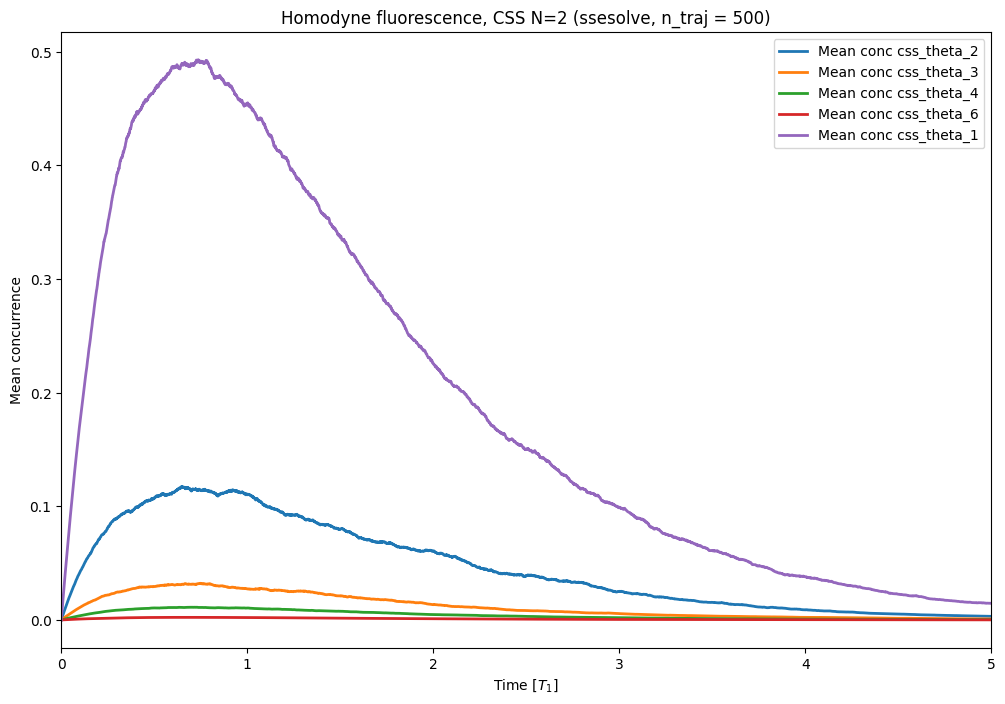

In [14]:
plt.figure(figsize=(12,8))


for state in my_name_states:
    line_sim, = plt.plot(times/T_1, hom_dfs[f"{state}"]['mean'], label=f"Mean conc {state}", linewidth=2)
    #plt.plot(times/T_1, theory, '--', label=f"Theo conc", color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.xlim(0, 5)
plt.xlabel(r"Time [$T_1$]")
plt.ylabel("Mean concurrence")
plt.title(f"Homodyne fluorescence, CSS N=2 (ssesolve, n_traj = {ntraj})")
plt.legend()
plt.show()